In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Options
csv_path = Path("job_transitions.csv")          # path to your CSV
freq = 0.1
smooth_seconds = 0.1                   # rolling mean window
out_path = Path("jobs_per_sec.png")   # optional save path
show_plot = True                      # display inline in notebook

# load & preprocess 
usecols = ["REAL_FINISH"]
df = pd.read_csv(csv_path, usecols=usecols)
df = df.dropna(subset=["REAL_FINISH"]).copy()
df["t_finish"] = pd.to_datetime(df["REAL_FINISH"], unit="s", utc=True)
df = df.sort_values("t_finish", kind="mergesort").reset_index(drop=True)

# aggregate completions per bin 
s = pd.Series(1, index=df["t_finish"])
rate = s.resample(freq).count().asfreq(freq, fill_value=0)

# smoothing
if smooth_seconds > 0:
    smoothed = rate.rolling(f"{smooth_seconds}s", min_periods=1, center=True).mean()
else:
    smoothed = None

#compute average throughput 
duration_s = (rate.index[-1] - rate.index[0]).total_seconds() or 1.0
avg_rate = len(df) / duration_s
title = f"Simulator throughput • avg ≈ {avg_rate:.2f} jobs/s • bins={freq} smooth={smooth_seconds}s"

# plot 
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(rate.index, rate.values, width=0.8, align="center", alpha=0.35, label=f"Per-bin count ({freq})")
if smoothed is not None:
    ax.plot(smoothed.index, smoothed.values, linewidth=2.0, label=f"Rolling mean ({smooth_seconds}s)")
ax.set_ylabel("Jobs per second" if freq.upper() == "1S" else f"Jobs per {freq}")
ax.set_xlabel("Real time (UTC)")
ax.set_title(title)
ax.legend(loc="upper left", frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(out_path, dpi=150)
if show_plot:
    plt.show()
plt.close(fig)

print(f"Saved plot to: {out_path}")


ValueError: Invalid frequency: 0.1

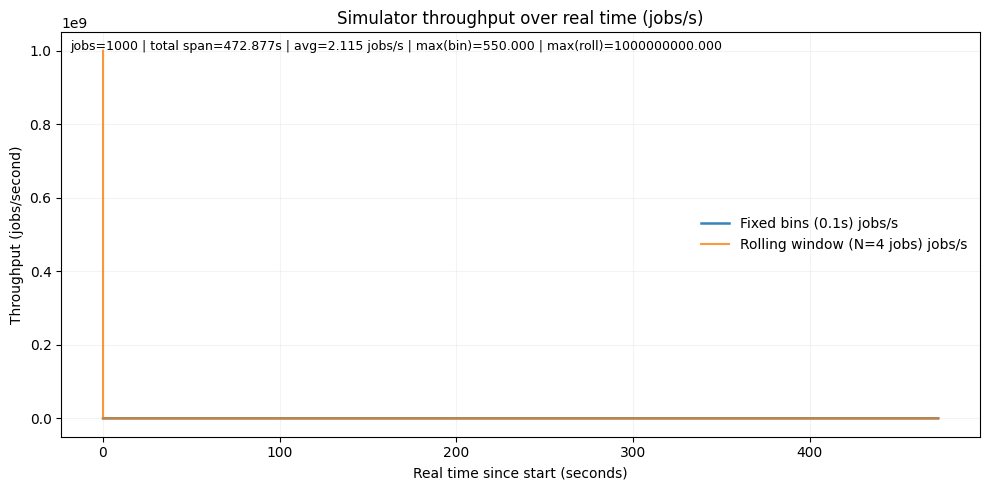

In [ ]:
# Jobs/sec over real time from a simulator trace
# ------------------------------------------------
# How it works:
# 1) Sorts rows by REAL_FINISH (to handle mild out-of-order arrival).
# 2) Computes two throughput curves:
#    a) Fixed real-time bins: jobs finished in each bin ÷ bin_width.
#    b) Rolling window by job count: N jobs / elapsed time across those N completions.
# 3) Plots both on the same time axis (seconds or minutes, configurable).
#
# Hard-coded params live in the "CONFIG" block below.

import io
import math
from textwrap import dedent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# CONFIG (edit these)
# -----------------------
USE_EMBEDDED_SAMPLE = False  # True = use SAMPLE_CSV below; False = read CSV_PATH
CSV_PATH = "job_transitions_lassen_250_10250.csv"  # only used when USE_EMBEDDED_SAMPLE=False
TIME_AXIS_UNITS = "seconds"               # "seconds" or "minutes"
BIN_WIDTH_SEC = 0.1                       # width of fixed time bins for rate curve (seconds)
ROLLING_WINDOW_JOBS = 4                 # N-jobs window for rolling jobs/sec (try 64..1024)
SMOOTH_HIST_WITH_GAUSSIAN = True          # visual smoothing of the binned curve
SMOOTH_SIGMA_BINS = 1.0                   # stddev in "bins" for the Gaussian smoothing
LINE_ALPHA = 0.9
GRID_ALPHA = 0.15

# Small embedded sample so this cell runs as-is. Replace with your file by setting USE_EMBEDDED_SAMPLE=False
SAMPLE_CSV = dedent("""\
trace_idx,jobid,nnodes,SUBMIT,START,FINISH,REAL_SUBMIT,REAL_START,REAL_FINISH,NODELIST
0,ƒ9anBnsJP,1,1534934333.000000,1534934333.000000,1534934635.000000,1761536848.141101,1761536848.746801,1761536848.794451,0
1,ƒ9b1m2HwV,1,1534934373.000000,1534934373.000000,1534934690.000000,1761536848.747298,1761536848.794156,1761536848.795149,1
2,ƒ9b2zBhU3,1,1534945299.000000,1534945299.000000,1534945613.000000,1761536848.795722,1761536848.841848,1761536848.888796,0
3,ƒ9b4Bs7iF,1,1534945301.000000,1534945301.000000,1534945622.000000,1761536848.842136,1761536848.888507,1761536848.889584,1
4,ƒ9b5R2XEo,1,1535123508.000000,1535123508.000000,1535123812.000000,1761536848.890190,1761536848.934597,1761536848.980656,0
5,ƒ9b6YFydy,1,1535123510.000000,1535123510.000000,1535123822.000000,1761536848.934900,1761536848.980313,1761536848.981472,1
6,ƒ9b8wcp8P,1,1535124916.000000,1535124916.000000,1535125302.000000,1761536849.028429,1761536849.074584,1761536849.167900,1
7,ƒ9b7mRPAX,1,1535124915.000000,1535124915.000000,1535125301.000000,1761536848.982176,1761536849.028100,1761536849.167131,0
8,ƒ9bA7pF6F,1,1535124919.000000,1535124919.000000,1535125304.000000,1761536849.074889,1761536849.120771,1761536849.168782,2
9,ƒ9bBJ1g47,1,1535124920.000000,1535124920.000000,1535125304.000000,1761536849.121074,1761536849.166834,1761536849.168863,3
10,ƒ9bCYf4s1,1,1536064751.000000,1536064751.000000,1536064768.000000,1761536849.169688,1761536849.214605,1761536849.214905,0
""")

# -----------------------
# Load & prep
# -----------------------
if USE_EMBEDDED_SAMPLE:
    df = pd.read_csv(io.StringIO(SAMPLE_CSV))
else:
    df = pd.read_csv(CSV_PATH)

# Ensure we have required columns
req_cols = {"REAL_START", "REAL_FINISH"}
missing = req_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Sort by REAL_FINISH to handle mild out-of-order completion.
df = df.sort_values("REAL_FINISH", kind="mergesort").reset_index(drop=True)

# Time origin = first REAL_START (could also pick first REAL_FINISH; either is fine as long as consistent)
t0 = float(df["REAL_START"].iloc[0])
t_finish = df["REAL_FINISH"].astype(float).values
t_finish_rel = t_finish - t0  # seconds since start

# -----------------------
# Fixed-bin jobs/sec
# -----------------------
if len(t_finish_rel) >= 2:
    t_end = t_finish_rel[-1]
else:
    t_end = (t_finish_rel[0] if len(t_finish_rel) == 1 else 0.0)

bin_edges = np.arange(0.0, t_end + BIN_WIDTH_SEC, BIN_WIDTH_SEC)
counts, edges = np.histogram(t_finish_rel, bins=bin_edges)
bin_centers = (edges[:-1] + edges[1:]) / 2.0
rate_bins = counts / float(BIN_WIDTH_SEC)

# Optional Gaussian smoothing for nicer visuals on spiky data
if SMOOTH_HIST_WITH_GAUSSIAN and len(rate_bins) > 3:
    from scipy.ndimage import gaussian_filter1d
    rate_bins_smooth = gaussian_filter1d(rate_bins.astype(float), sigma=SMOOTH_SIGMA_BINS, mode="nearest")
else:
    rate_bins_smooth = rate_bins

# -----------------------
# Rolling N-jobs window jobs/sec
# -----------------------
N = ROLLING_WINDOW_JOBS
tf = t_finish_rel
rates_roll = np.full_like(tf, np.nan, dtype=float)

# Compute windowed rates; for i >= N-1: rate = N / (t[i] - t[i-(N-1)])
if len(tf) > 1:
    # Use max(1, ...) in case consecutive finishes share timestamps in the same second
    for i in range(len(tf)):
        j0 = max(0, i - (N - 1))
        jobs_in_window = i - j0 + 1
        dt = tf[i] - tf[j0]
        if dt <= 0:
            # If multiple completions have identical timestamps, treat dt as tiny to avoid inf
            dt = 1e-9
        rates_roll[i] = jobs_in_window / dt
else:
    rates_roll[:] = np.nan

# -----------------------
# Summary stats
# -----------------------
total_jobs = len(df)
total_time = (t_finish_rel[-1] - t_finish_rel[0]) if total_jobs > 1 else 0.0
avg_rate_overall = (total_jobs / total_time) if total_time > 0 else float("nan")
max_rate_bin = float(np.nanmax(rate_bins)) if len(rate_bins) else float("nan")
max_rate_roll = float(np.nanmax(rates_roll)) if np.isfinite(rates_roll).any() else float("nan")

# -----------------------
# Plot
# -----------------------
def _to_axis_units(x_seconds: np.ndarray):
    if TIME_AXIS_UNITS.lower().startswith("min"):
        return x_seconds / 60.0
    return x_seconds

x_label_units = "minutes" if TIME_AXIS_UNITS.lower().startswith("min") else "seconds"

fig, ax = plt.subplots(figsize=(10, 5))

# Binned curve
ax.plot(
    _to_axis_units(bin_centers),
    rate_bins_smooth,
    label=f"Fixed bins ({BIN_WIDTH_SEC:g}s) jobs/s",
    linewidth=1.8,
    alpha=LINE_ALPHA,
)

# Rolling jobs curve (plot only where we have values)
ax.plot(
    _to_axis_units(t_finish_rel),
    rates_roll,
    label=f"Rolling window (N={N} jobs) jobs/s",
    linewidth=1.5,
    alpha=LINE_ALPHA * 0.9,
)

ax.set_title("Simulator throughput over real time (jobs/s)")
ax.set_xlabel(f"Real time since start ({x_label_units})")
ax.set_ylabel("Throughput (jobs/second)")
ax.grid(True, which="both", alpha=GRID_ALPHA)
ax.legend(frameon=False, loc="best")

# Nice annotation with summary
summary = (
    f"jobs={total_jobs} | total span={t_end:.3f}s | "
    f"avg={avg_rate_overall:.3f} jobs/s | "
    f"max(bin)={max_rate_bin:.3f} | max(roll)={max_rate_roll:.3f}"
)
ax.text(
    0.01, 0.98, summary,
    transform=ax.transAxes, va="top", ha="left",
    fontsize=9
)

plt.tight_layout()
plt.show()


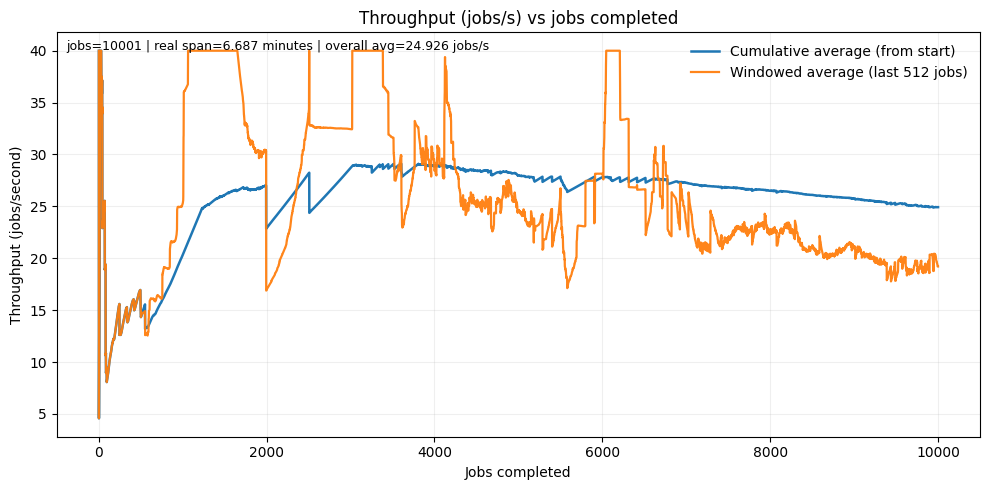

In [2]:
# Rolling average jobs/second vs number of jobs completed
# -------------------------------------------------------

import io
from textwrap import dedent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# CONFIG (edit these)
# -----------------------
USE_EMBEDDED_SAMPLE = False   # set False to read a real CSV file
CSV_PATH = "job_transitions.csv" 

WINDOW_SIZE_JOBS = 512     # sliding window size W (set to 1 for per-job instantaneous rate)
EPS = 1e-9                # protects against zero/negative dt
CLIP_P99_YAXIS = True           # clip y to 99th percentile for visibility

# -----------------------
# Load and prep
# -----------------------
df = pd.read_csv(io.StringIO(SAMPLE_CSV)) if USE_EMBEDDED_SAMPLE else pd.read_csv(CSV_PATH)
df = df.sort_values("REAL_FINISH", kind="mergesort").reset_index(drop=True)

t_start0 = float(df["REAL_START"].min())
t_finish = df["REAL_FINISH"].astype(float).values
t_elapsed = np.maximum(t_finish - t_start0, EPS)  # elapsed real seconds for each completion

N = len(df)
jobs_completed = np.arange(1, N + 1, dtype=float)

# -----------------------
# 1) Cumulative average throughput
# -----------------------
throughput_cum = jobs_completed / t_elapsed  

# -----------------------
# 2) Sliding-window average throughput over last W jobs
# -----------------------
W = max(1, int(WINDOW_SIZE_JOBS))
throughput_win = np.empty(N, dtype=float)
for i in range(N):
    k = min(W, i + 1)
    j0 = i - (k - 1)
    dt = t_finish[i] - t_finish[j0]
    if dt <= 0:
        dt = EPS
    throughput_win[i] = k / dt

# Optional clipping for readability
y1, y2 = throughput_cum.copy(), throughput_win.copy()
if CLIP_P99_YAXIS:
    # cap = np.nanpercentile(np.concatenate([y1, y2]), 95)
    cap = 40
    y1 = np.clip(y1, 0, cap)
    y2 = np.clip(y2, 0, cap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(jobs_completed, y1, label="Cumulative average (from start)", linewidth=1.8)
ax.plot(jobs_completed, y2, label=f"Windowed average (last {W} jobs)", linewidth=1.6, alpha=0.95)

ax.set_title("Throughput (jobs/s) vs jobs completed")
ax.set_xlabel("Jobs completed")
ax.set_ylabel("Throughput (jobs/second)")
ax.grid(True, which="both", alpha=0.2)
ax.legend(frameon=False, loc="best")

# -----------------------
# Smart time-unit display
# -----------------------
total_real = float(t_elapsed.max()) if N else 0.0
overall_avg = float(throughput_cum[-1]) if N else float("nan")

if total_real >= 3600:
    time_val = total_real / 3600
    time_unit = "hours"
elif total_real >= 60:
    time_val = total_real / 60
    time_unit = "minutes"
else:
    time_val = total_real
    time_unit = "seconds"

ax.text(
    0.01, 0.98,
    f"jobs={N} | real span={time_val:.3f} {time_unit} | overall avg={overall_avg:.3f} jobs/s",
    transform=ax.transAxes,
    va="top", ha="left", fontsize=9
)

plt.tight_layout()
plt.show()


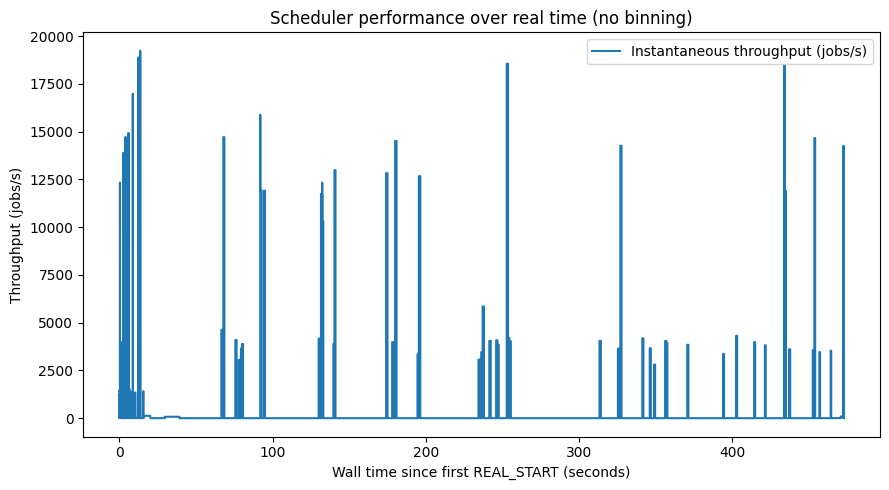

,elapsed_sec,finished_here,dt_prev_sec,instant_jobs_per_s
0,0.047650,1,NaN,NaN
1,0.048348,1,0.000698,1432.480874
2,0.141995,1,0.093647,10.678398
3,0.142783,1,0.000788,1269.078366
4,0.233855,1,0.091072,10.980342
5,0.234671,1,0.000816,1225.329828
6,0.420330,1,0.185659,5.386221
7,0.421099,1,0.000769,1300.156231
8,0.421981,1,0.000882,1133.902136
9,0.422062,1,0.000081,12336.188235


In [6]:
# Plain, no-binning throughput plot for your scheduler run
# Paste into a Jupyter cell. Only change CSV_PATH if needed.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# Hard-coded parameters
# -----------------------
CSV_PATH = "job_transitions.csv"    # path to your CSV with the exact headers you showed
USE_MINUTES = False       # False -> seconds on x-axis; True -> minutes
SHOW_CUMULATIVE = False   # Optional overlay of cumulative average jobs/s

# -----------------------
# Load & basic cleaning
# -----------------------
cols_needed = [
    "trace_idx","jobid","nnodes","SUBMIT","START","FINISH",
    "REAL_SUBMIT","REAL_START","REAL_FINISH","NODELIST"
]

df = pd.read_csv(CSV_PATH)
missing = [c for c in cols_needed if c not in df.columns]
if missing:
    raise ValueError(f"CSV missing expected columns: {missing}")

# Focus on real wall-clock times (float seconds since epoch)
s = df["REAL_START"].astype(float)
f = df["REAL_FINISH"].astype(float)

# Sort by real finish time; stable for ties via start time then index
order = np.lexsort((df.index.values, s.values, f.values))
df = df.iloc[order].reset_index(drop=True)

# Reference time (t0) as earliest REAL_START
t0 = df["REAL_START"].min()

# Group by unique REAL_FINISH timestamps:
grp = df.groupby("REAL_FINISH", sort=True).size().rename("count").reset_index()

# Ensure float type
grp["REAL_FINISH"] = grp["REAL_FINISH"].astype(float)
grp = grp.sort_values("REAL_FINISH").reset_index(drop=True)

# Compute elapsed time since previous unique timestamp
finish_times = grp["REAL_FINISH"].values
counts = grp["count"].values

# For instantaneous throughput, define intervals between successive unique finish times.
# Throughput_i = (#jobs that finished at time_i) / (time_i - time_{i-1})
# For the first point, there is no prior interval; we skip it (or set NaN).
dt = np.diff(finish_times, prepend=np.nan)

throughput = np.empty_like(finish_times, dtype=float)
throughput[:] = np.nan
mask_valid = dt > 0
throughput[mask_valid] = counts[mask_valid] / dt[mask_valid]
# If dt == 0 (shouldn't happen for unique times), stays NaN

# X-axis as elapsed wall time since t0
elapsed = finish_times - t0

# Optional unit conversion
x_label_unit = "seconds"
if USE_MINUTES:
    elapsed = elapsed / 60.0
    x_label_unit = "minutes"

# -----------------------
# Optional cumulative average throughput overlay
# -----------------------
if SHOW_CUMULATIVE:
    cum_jobs = counts.cumsum().astype(float)
    cum_time = finish_times - t0
    cum_avg = np.where(cum_time > 0, cum_jobs / cum_time, np.nan)
else:
    cum_jobs = cum_time = cum_avg = None

# -----------------------
# Plot (single axes, no fancy styling)
# -----------------------
plt.figure(figsize=(9, 5))
# Step plot to reflect piecewise-constant rate over each interval (right-aligned)
plt.step(elapsed, throughput, where="post", label="Instantaneous throughput (jobs/s)")

if SHOW_CUMULATIVE:
    plt.plot(
        elapsed, cum_avg,
        linewidth=1.0,
        label="Cumulative average throughput (jobs/s)"
    )

plt.xlabel(f"Wall time since first REAL_START ({x_label_unit})")
plt.ylabel("Throughput (jobs/s)")
plt.title("Scheduler performance over real time (no binning)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# -----------------------
# (Optional) quick peek at the computed series
# -----------------------
preview = pd.DataFrame({
    "elapsed_"+("min" if USE_MINUTES else "sec"): elapsed,
    "finished_here": counts,
    "dt_prev_"+("min" if USE_MINUTES else "sec"): (dt/60.0 if USE_MINUTES else dt),
    "instant_jobs_per_s": throughput,
})
preview.head(10)
